In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
TF = pd.read_csv('Neuropep_TF_corr_hypo_07072026.csv', index_col = 'Unnamed: 0').T
UR = pd.read_csv('TF_unregulated_corr_hypo_ncontrols5_07092026.csv', index_col = 'Unnamed: 0').T

In [5]:
TF.shape[0]

31

In [6]:
fin_org = ['mouse' for i in range(TF.shape[0])] + ['vole' for i in range(TF.shape[0])] + ['quail' for i in range(TF.shape[0])] + ['anole' for i in range(TF.shape[0])] + ['xenopus' for i in range(TF.shape[0])] + ['zebrafish' for i in range(TF.shape[0])] + ['mouse' for i in range(UR.shape[0])] + ['vole' for i in range(UR.shape[0])] + ['quail' for i in range(UR.shape[0])] + ['anole' for i in range(UR.shape[0])] + ['xenopus' for i in range(UR.shape[0])] + ['zebrafish' for i in range(UR.shape[0])]
fin_val = list(TF['mm']) + list(TF['mo']) + list(TF['cj']) + list(TF['ac']) + list(TF['xt']) + list(TF['dr']) + list(UR['mm']) + list(UR['mo']) + list(UR['cj']) + list(UR['ac']) + list(UR['xt']) + list(UR['dr'])
fin_genetype = ['TF' for i in range(TF.shape[0] * 6)] + ['Unreg' for i in range(UR.shape[0] * 6)]

In [7]:
len(fin_org),len(fin_val),len(fin_genetype),

(1116, 1116, 1116)

In [8]:
plt_df = pd.DataFrame(data = [fin_org,fin_val,fin_genetype], columns = [i for i in range(len(fin_genetype))], index = ['org','val','genetype']).T

In [9]:
plt_df[plt_df['org'] == 'mouse']

,org,val,genetype
0,mouse,0.405647,TF
1,mouse,0.309298,TF
2,mouse,0.5974,TF
3,mouse,0.424799,TF
4,mouse,0.332997,TF
...,...,...,...
336,mouse,0.444693,Unreg
337,mouse,0.444548,Unreg
338,mouse,0.445311,Unreg
339,mouse,0.445334,Unreg


/scratch/miniconda/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


(array([3., 6., 3., 5., 1., 1., 2., 0., 0., 2.]),
 array([-0.1339659913942588, -0.0849711078641461, -0.0359762243340334,
        0.013018659196079307, 0.062013542726192, 0.1110084262563047,
        0.1600033097864174, 0.20899819331653008, 0.2579930768466428,
        0.3069879603767555, 0.3559828439068682], dtype=object),
 <BarContainer object of 10 artists>)

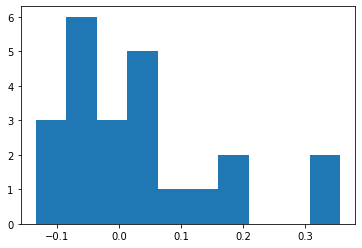

In [8]:
plt.hist(plt_df[plt_df['org'] == 'quail'][plt_df['genetype'] == 'Unreg']['val'], bins = 10)

In [10]:
plt_df['val'] = plt_df['val'].astype(float)

In [15]:
stat, p = stats.mannwhitneyu(plt_df[(plt_df['org'] == 'zebrafish') & (plt_df['genetype'] == 'TF')]['val'].dropna(), 
                         plt_df[(plt_df['org'] == 'zebrafish') & (plt_df['genetype'] == 'Unreg')]['val'].dropna(), alternative = 'greater')
stat,p

(1137.0, 0.5315218973149924)

In [16]:
df_stat =pd.DataFrame(data = [0.006965945416048793,0.011674730592875193,0.12304503223324736,0.484710612535736,0.5315218973149924], columns = [0], index = ['MO','CJ','AC','XT','DR'])

In [17]:
df_stat.to_csv('Figures/Figures_07072026/Figure3G_pvals_pearson_ncontrols5_07092026.csv')

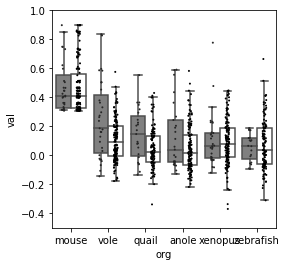

In [18]:
plt.figure(figsize=(4,4))
ax = sns.boxplot(data=plt_df, x='org', y='val', hue='genetype',
                 palette={'TF': 'grey', 'Unreg': 'white'},fliersize = 0)

sns.stripplot(data=plt_df, x='org', y='val', hue='genetype',
              color='black', dodge=True, s = 2)

# Remove the doubled legend from boxplot
ax.legend_.remove()  # then add back manually if needed
plt.ylim(-0.5,1)

plt.savefig('Figures/Figures_07072026/Figure3G_unreg_NP_pearson_ncontrol5_07092026.svg')
plt.savefig('Figures/Figures_07072026/Figure3G_unreg_NP_pearson_ncontrol5_07092026.png',dpi =300,bbox_inches = 'tight')
plt.savefig('Figures/Figures_07072026/Figure3G_unreg_NP_pearson_ncontrol5_07092026.pdf')